# 💊 India’s Medicine Price Gap Analyzer

## Problem Statement
India is the **‘pharmacy of the world’**, producing medicines for global markets.
Yet Indian consumers often pay vastly different prices for medicines containing
the exact same chemical molecule. A branded Paracetamol tablet can cost 10x more
than a generic alternative with identical composition.

## Objective
This analysis investigates:
1. How large is the price gap between branded and generic medicines in India?
2. Which molecules have the widest price variation?
3. Which manufacturers charge the highest premium over the cheapest alternative?
4. Can we build an ‘Affordability Index’ to help consumers find cheaper alternatives?

## Methodology
- Prices are **normalized by pack size** (price per tablet/ml) for fair comparison
- Outliers are **investigated and flagged**, not blindly removed
- 56% empty `short_composition2` is treated as single-ingredient drugs, not missing data
- Comparisons are done within the **same formulation type** (tablet vs tablet, not tablet vs injection)

## Dataset
250,000+ Indian medicines from the A-Z Medicine Dataset (Kaggle)
Columns: medicine name, price, manufacturer, composition (salt/molecule)



## Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.width', None)
print('Setup complete!')


Setup complete!


## Data Loading & First Look

In [3]:
df = pd.read_csv('A_Z_medicines_dataset_of_India.csv')

print(f'Dataset shape: {df.shape[0]:,} medicines x {df.shape[1]} columns')
print(f'\nColumn names: {list(df.columns)}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nFirst 5 rows:')
df.head()


Dataset shape: 253,973 medicines x 9 columns

Column names: ['id', 'name', 'price(₹)', 'Is_discontinued', 'manufacturer_name', 'type', 'pack_size_label', 'short_composition1', 'short_composition2']

Data types:
id                      int64
name                   object
price(₹)              float64
Is_discontinued          bool
manufacturer_name      object
type                   object
pack_size_label        object
short_composition1     object
short_composition2     object
dtype: object

First 5 rows:


,id,name,price(₹),Is_discontinued,manufacturer_name,type,pack_size_label,short_composition1,short_composition2
0,1,Augmentin 625 Duo Tablet,223.42,False,Glaxo SmithKline Pharmaceuticals Ltd,allopathy,strip of 10 tablets,Amoxycillin (500mg),Clavulanic Acid (125mg)
1,2,Azithral 500 Tablet,132.36,False,Alembic Pharmaceuticals Ltd,allopathy,strip of 5 tablets,Azithromycin (500mg),NaN
2,3,Ascoril LS Syrup,118.00,False,Glenmark Pharmaceuticals Ltd,allopathy,bottle of 100 ml Syrup,Ambroxol (30mg/5ml),Levosalbutamol (1mg/5ml)
3,4,Allegra 120mg Tablet,218.81,False,Sanofi India Ltd,allopathy,strip of 10 tablets,Fexofenadine (120mg),NaN
4,5,Avil 25 Tablet,10.96,False,Sanofi India Ltd,allopathy,strip of 15 tablets,Pheniramine (25mg),NaN


### Let’s check which columns have missing data and how much.

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
missing_df


Columns with missing values:


,Missing Count,Missing %
short_composition2,141802,55.83


### Quick overview of price range, manufacturer count, and composition diversity.

In [5]:
print(f'Price range: \u20B9{df["price(\u20B9)"].min():.2f} to \u20B9{df["price(\u20B9)"].max():.2f}')
print(f'Average price: \u20B9{df["price(\u20B9)"].mean():.2f}')
print(f'Median price: \u20B9{df["price(\u20B9)"].median():.2f}')
print(f'\nUnique manufacturers: {df["manufacturer_name"].nunique()}')
print(f'Unique compositions (primary salt): {df["short_composition1"].nunique()}')
print(f'Discontinued medicines: {df["Is_discontinued"].sum()}')

Price range: ₹0.00 to ₹436000.00
Average price: ₹270.53
Median price: ₹79.00

Unique manufacturers: 7648
Unique compositions (primary salt): 8523
Discontinued medicines: 7905


## Data Cleaning Strategy

Our cleaning follows these principles:
1. **Remove** discontinued medicines (no longer sold)
2. **Remove** zero/negative prices (data entry errors)
3. **Flag** (not delete) expensive medicines — a ₹4L cancer drug is real data
4. **Recognize** empty `short_composition2` as single-ingredient drugs, not missing data
5. **Normalize** prices by pack size — ₹100 for 10 tablets = ₹10/tablet

### Removing Discontinued Medicines

In [6]:
print(f'Before removing discontinued: {len(df):,} rows')
df = df[df['Is_discontinued'] == False].copy()
print(f'After removing discontinued: {len(df):,} rows')
df.drop(columns=['Is_discontinued'], inplace=True)

Before removing discontinued: 253,973 rows
After removing discontinued: 246,068 rows


### Price Cleaning
I remove clearly erroneous prices (zero/negative) but flag expensive medicines rather than deleting them — cancer drugs and biologics are legitimately expensive.

In [7]:
df.rename(columns={'price(\u20B9)': 'price'}, inplace=True)

# Remove zero/negative prices (clearly erroneous)
print(f'Zero or negative prices: {(df["price"] <= 0).sum()}')
df = df[df['price'] > 0].copy()

# INVESTIGATE extreme values instead of blind removal
upper_limit = df['price'].quantile(0.999)
print(f'\nPrice 99.9th percentile: \u20B9{upper_limit:.2f}')
print(f'Medicines above 99.9th percentile: {(df["price"] > upper_limit).sum()}')

print(f'\nLet\'s inspect these expensive medicines:')
expensive = df[df['price'] > upper_limit][['name', 'price', 'manufacturer_name', 'short_composition1']]
display(expensive.sort_values('price', ascending=False))

# FLAG them instead of deleting
df['is_premium_priced'] = df['price'] > upper_limit
print(f'\nFlagged {df["is_premium_priced"].sum()} premium-priced medicines')
print(f'These are KEPT in the dataset but flagged for reference')
print(f'Final dataset size: {len(df):,}')

Zero or negative prices: 4

Price 99.9th percentile: ₹25000.00
Medicines above 99.9th percentile: 245

Let's inspect these expensive medicines:


,name,price,manufacturer_name,short_composition1
113862,Imbruvica 140mg Capsule,436000.00,Janssen Pharmaceuticals,Ibrutinib (140mg)
217021,Tecentriq 1200mg Injection,396725.00,Roche Products India Pvt Ltd,Atezolizumab (60mg/ml)
243971,Xtandi 40mg Soft Capsule,335635.00,Astellas Pharma Inc,Enzalutamide (40mg)
28711,Besponsa 1mg Injection,330000.00,Pfizer Ltd,Inotuzumab Ozogamacin (1mg)
113861,Imbruvica 140mg Capsule,328000.00,Janssen Pharmaceuticals,Ibrutinib (140mg)
...,...,...,...,...
39350,Cyendiv 150mg Soft Gelatin Capsule,25985.00,Boehringer Ingelheim,Nintedanib (150mg)
85199,Faslodex 250mg Injection,25573.00,AstraZeneca,Fulvestrant (250mg)
24126,Acozolo 250 Capsule,25520.00,Accord Pharmaceuticals,Temozolomide (250mg)
82418,Erlostar Tablet,25500.00,Lupin Ltd,Erlotinib (NA)



Flagged 245 premium-priced medicines
These are KEPT in the dataset but flagged for reference
Final dataset size: 246,064


### Single vs Combination Drugs
56% of medicines have no secondary composition. It means the medicine contains only one active ingredient. I created a flag to analyze pricing differences between single-ingredient and combination drugs.

In [8]:
comp2_missing = df['short_composition2'].isna().sum()
comp2_pct = comp2_missing / len(df) * 100
print(f'short_composition2 is empty: {comp2_missing:,} rows ({comp2_pct:.1f}%)')
print(f'short_composition2 is filled: {len(df) - comp2_missing:,} rows ({100-comp2_pct:.1f}%)')

df['is_combination_drug'] = df['short_composition2'].notna()
print(f'\nSingle-ingredient medicines: {(~df["is_combination_drug"]).sum():,}')
print(f'Combination drugs (2+ salts): {df["is_combination_drug"].sum():,}')

print(f'\nMedian price \u2014 Single salt: \u20B9{df[~df["is_combination_drug"]]["price"].median():.2f}')
print(f'Median price \u2014 Combination:  \u20B9{df[df["is_combination_drug"]]["price"].median():.2f}')


short_composition2 is empty: 136,744 rows (55.6%)
short_composition2 is filled: 109,320 rows (44.4%)

Single-ingredient medicines: 136,744
Combination drugs (2+ salts): 109,320

Median price — Single salt: ₹72.50
Median price — Combination:  ₹85.00


### Extract salt name and dosage

In [9]:
def extract_salt(comp):
    if pd.isna(comp):
        return None
    comp = str(comp).strip()
    if '(' in comp:
        salt = comp[:comp.index('(')].strip()
        dosage = comp[comp.index('(')+1:comp.index(')')].strip()
        return salt, dosage
    return comp, None

df[['salt_name', 'dosage']] = df['short_composition1'].apply(
    lambda x: pd.Series(extract_salt(x)))

before = len(df)
df = df.dropna(subset=['salt_name']).copy()
print(f'Dropped {before - len(df)} rows with no composition info')
print(f'Unique salts: {df["salt_name"].nunique()}')
print(f'\nTop 10 salts by medicine count:')
df['salt_name'].value_counts().head(10)


Dropped 0 rows with no composition info
Unique salts: 1523

Top 10 salts by medicine count:


salt_name
Cefixime                8820
Domperidone             8756
Aceclofenac             8562
Amoxycillin             8373
Ofloxacin               6646
Ceftriaxone             6133
Cefpodoxime Proxetil    6015
Levocetirizine          5897
Glimepiride             5102
Azithromycin            4766
Name: count, dtype: int64

### Create full composition column

In [10]:
# Combine composition1 + composition2 for exact drug matching
# Two medicines are truly interchangeable only if BOTH compositions match
df['full_composition'] = (df['short_composition1'].fillna('')
    + ' + ' + df['short_composition2'].fillna('')).str.strip(' +')

print(f'Unique full compositions: {df["full_composition"].nunique()}')
print(f'\nSample full compositions:')
df['full_composition'].value_counts().head(5)


Unique full compositions: 11246

Sample full compositions:


full_composition
Aceclofenac (100mg)  +  Paracetamol (325mg)    4661
Pantoprazole (40mg)                            2611
Domperidone (30mg)  +  Rabeprazole (20mg)      2595
Levocetirizine (5mg)  +  Montelukast (10mg)    2260
Rabeprazole (20mg)                             2068
Name: count, dtype: int64

### Standardize manufacturer names

In [11]:
df['manufacturer_name'] = df['manufacturer_name'].str.strip()

print(f'Unique manufacturers: {df["manufacturer_name"].nunique()}')
print(f'\nTop 10 manufacturers by number of medicines:')
df['manufacturer_name'].value_counts().head(10)

Unique manufacturers: 7640

Top 10 manufacturers by number of medicines:


manufacturer_name
Sun Pharmaceutical Industries Ltd    2542
Intas Pharmaceuticals Ltd            2169
Cipla Ltd                            2050
Torrent Pharmaceuticals Ltd          1801
Alkem Laboratories Ltd               1690
Lupin Ltd                            1587
Zydus Cadila                         1551
Micro Labs Ltd                       1188
Abbott                               1131
Macleods Pharmaceuticals Pvt Ltd     1090
Name: count, dtype: int64

## Pack Size Normalization
Comparing raw MRP across brands is misleading because pack sizes differ. A ₹100 strip of 10 tablets and a ₹50 strip of 5 tablets have the same per-unit cost of ₹10/tablet. I extracted pack quantity and compute price_per_unit for fair comparisons.

### Price per unit normalization

In [12]:
# Extract numeric quantity from pack_size_label
df['pack_qty'] = df['pack_size_label'].str.extract(r'(\d+\.?\d*)').astype(float)

# Calculate price per unit
df['price_per_unit'] = (df['price'] / df['pack_qty']).round(4)

print(f'Pack quantity extracted for: {df["pack_qty"].notna().sum():,} / {len(df):,} rows')
print(f'Failed to extract: {df["pack_qty"].isna().sum()}')

print(f'\nSample check - Paracetamol 500mg:')
sample = df[df['full_composition'] == 'Paracetamol (500mg)'][
    ['name', 'price', 'pack_size_label', 'pack_qty', 'price_per_unit']].head(10)
display(sample)

Pack quantity extracted for: 246,064 / 246,064 rows
Failed to extract: 0

Sample check - Paracetamol 500mg:


,name,price,pack_size_label,pack_qty,price_per_unit
1254,Agmamol 500mg Tablet,14.00,strip of 15 tablets,15.00,0.93
1471,Arden 500mg Tablet,16.92,strip of 15 tablets,15.00,1.13
1902,Acimol 500mg Tablet,6.00,strip of 10 tablets,10.00,0.60
1964,Amol 500mg Tablet,3.56,strip of 10 tablets,10.00,0.36
3143,Anglopar 500mg Tablet,2.86,strip of 10 tablets,10.00,0.29
3711,Adwin 500mg Tablet,19.75,strip of 10 tablets,10.00,1.98
3883,Algina Tablet,6.91,strip of 10 tablets,10.00,0.69
3943,Amidol Tablet,21.77,strip of 10 tablets,10.00,2.18
4358,Admol 500mg Tablet DT,11.00,strip of 10 tablet dt,10.00,1.10
4400,April 500mg Tablet,6.00,strip of 10 tablets,10.00,0.60


### Extract formulation type

In [13]:
df['pack_type'] = df['pack_size_label'].str.extract(
    r'(tablets?|capsules?|syrups?|dry syrups?|injections?|creams?|gels?|drops?|powders?|solutions?|ointments?|oral suspensions?|suspensions?|vials?|tubes?|sachets?|ampoules?|eye drops?)',
    flags=re.IGNORECASE, expand=False).str.lower()

df['pack_type'] = df['pack_type'].str.rstrip('s')
df['pack_type'] = df['pack_type'].replace({
    'dry syrup': 'syrup', 'oral suspension': 'suspension',
    'eye drop': 'drop', 'ampoule': 'injection'})
df['pack_type'] = df['pack_type'].fillna('other')

print(df['pack_type'].value_counts())


pack_type
tablet        147928
vial           28337
capsule        20552
syrup          16415
suspension      8980
tube            7929
drop            5068
other           4744
injection       2738
solution        1745
gel             1033
powder           371
sachet           197
cream             21
ointment           6
Name: count, dtype: int64


### Post-cleaning summary

In [14]:
print('=== CLEANED DATASET SUMMARY ===')
print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns)}')
print(f'\nNew columns created during cleaning:')
print('  - salt_name: extracted molecule name')
print('  - dosage: extracted dosage')
print('  - full_composition: composition1 + composition2 combined')
print('  - is_combination_drug: True if medicine has 2+ salts')
print('  - is_premium_priced: True if above 99.9th percentile')
print('  - pack_qty: numeric quantity from pack label')
print('  - price_per_unit: price / pack_qty (for fair comparison)')
print('  - pack_type: formulation type (tablet, capsule, syrup, etc.)')
print(f'\nRemaining missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\n{df.describe()}')

=== CLEANED DATASET SUMMARY ===
Rows: 246,064
Columns: 16

New columns created during cleaning:
  - salt_name: extracted molecule name
  - dosage: extracted dosage
  - full_composition: composition1 + composition2 combined
  - is_combination_drug: True if medicine has 2+ salts
  - is_premium_priced: True if above 99.9th percentile
  - pack_qty: numeric quantity from pack label
  - price_per_unit: price / pack_qty (for fair comparison)
  - pack_type: formulation type (tablet, capsule, syrup, etc.)

Remaining missing values:
short_composition2    136744
dtype: int64

             id     price  pack_qty  price_per_unit
count 246064.00 246064.00 246064.00       246064.00
mean  126935.38    265.01     17.56          102.79
std    73290.83   3028.03     33.70         1555.69
min        1.00      1.05      0.05            0.01
25%    63454.75     48.00     10.00            3.90
50%   126870.50     79.00     10.00            8.37
75%   190445.25    140.00     10.00           18.00
max   253973

## Univariate Analysis

### Price Distribution
- The raw price distribution is heavily right-skewed due to specialty drugs (cancer, immunotherapy). The log-scale view reveals the true shape — most medicines cost between ₹30–₹300, with a peak around ₹100.
- The raw distribution shows extreme right-skew, justifying our decision to keep premium-priced medicines flagged rather than deleted — they represent real but rare high-cost drugs.

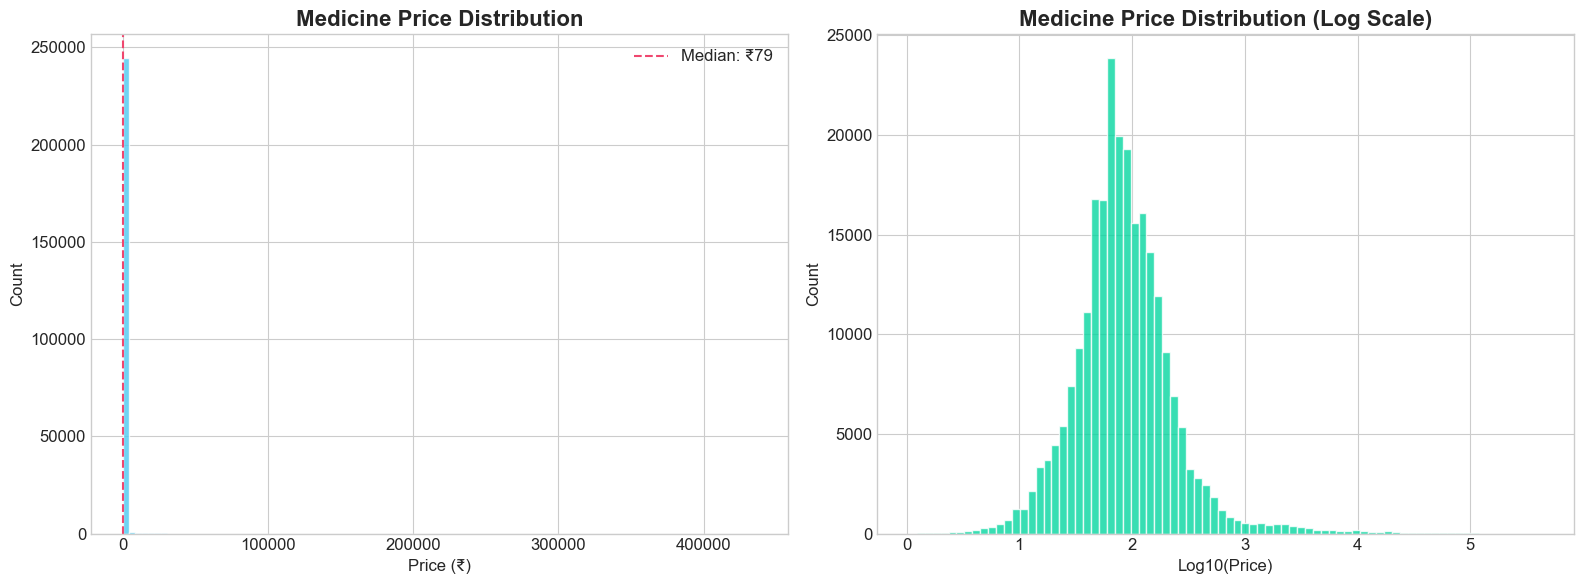

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['price'], bins=100, color='#4CC9F0', edgecolor='white', alpha=0.8)
axes[0].set_title('Medicine Price Distribution')
axes[0].set_xlabel('Price (\u20B9)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['price'].median(), color='#EF476F', linestyle='--',
                label=f'Median: \u20B9{df["price"].median():.0f}')
axes[0].legend()

axes[1].hist(np.log10(df['price']), bins=80, color='#06D6A0', edgecolor='white', alpha=0.8)
axes[1].set_title('Medicine Price Distribution (Log Scale)')
axes[1].set_xlabel('Log10(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



### Top Manufacturers by Product Count
India’s pharma market is dominated by a few large players. Sun Pharma, Intas, and Cipla together account for thousands of products.

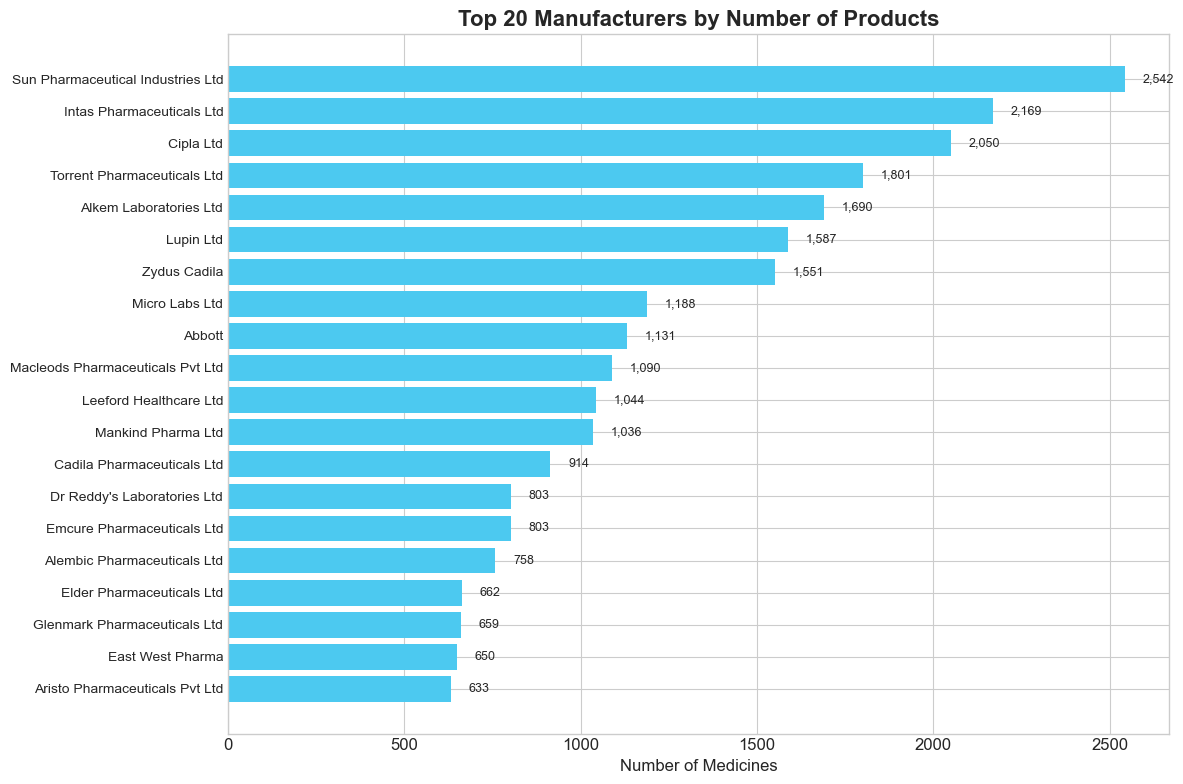

In [16]:
top_mfg = df['manufacturer_name'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(top_mfg)), top_mfg.values, color='#4CC9F0')
ax.set_yticks(range(len(top_mfg)))
ax.set_yticklabels(top_mfg.index, fontsize=10)
ax.set_xlabel('Number of Medicines')
ax.set_title('Top 20 Manufacturers by Number of Products')
ax.invert_yaxis()

for i, v in enumerate(top_mfg.values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('02_top_manufacturers.png', dpi=150, bbox_inches='tight')
plt.show()


### Most Common Salts/Molecules
These are the most competitive molecules in the Indian market — the more brands selling the same salt, the more price comparison matters.

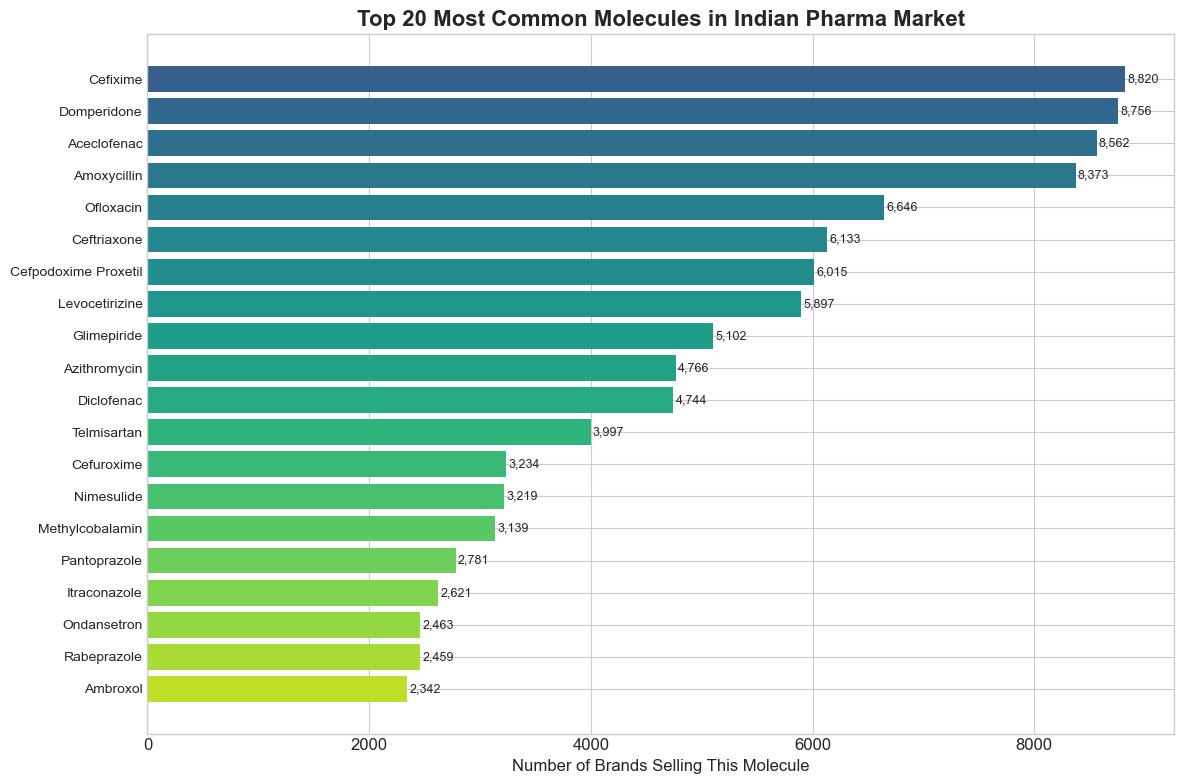

In [17]:
top_salts = df['salt_name'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_salts)))
ax.barh(range(len(top_salts)), top_salts.values, color=colors)
ax.set_yticks(range(len(top_salts)))
ax.set_yticklabels(top_salts.index, fontsize=10)
ax.set_xlabel('Number of Brands Selling This Molecule')
ax.set_title('Top 20 Most Common Molecules in Indian Pharma Market')
ax.invert_yaxis()

for i, v in enumerate(top_salts.values):
    ax.text(v + 20, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('03_top_salts.png', dpi=150, bbox_inches='tight')
plt.show()


### Medicine Formulation Types
I extracted formulation type from pack labels using regex. Tablets dominate at ~60%, with capsules, vials, and syrups as the next most common forms.

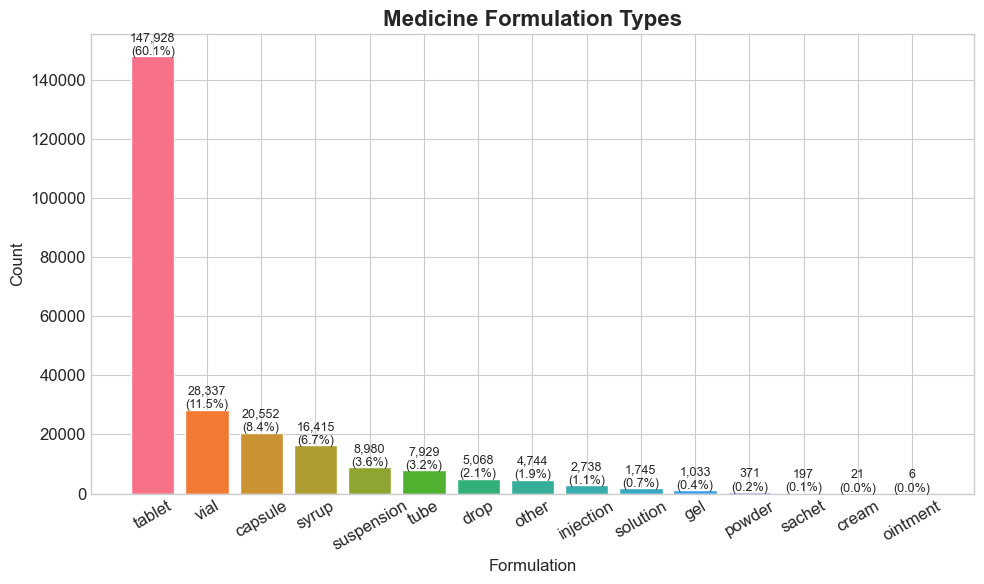

In [18]:
pack_counts = df['pack_type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(pack_counts.index, pack_counts.values,
              color=sns.color_palette('husl', len(pack_counts)), edgecolor='white')
ax.set_title('Medicine Formulation Types')
ax.set_xlabel('Formulation')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)

for bar, v in zip(bars, pack_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 500,
            f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('04_pack_types.png', dpi=150, bbox_inches='tight')
plt.show()


### Single-Ingredient vs Combination Drugs
56% of medicines contain a single active ingredient, while 45% are combination drugs (2+ salts). I compared their pricing to see if combining molecules commands a premium.

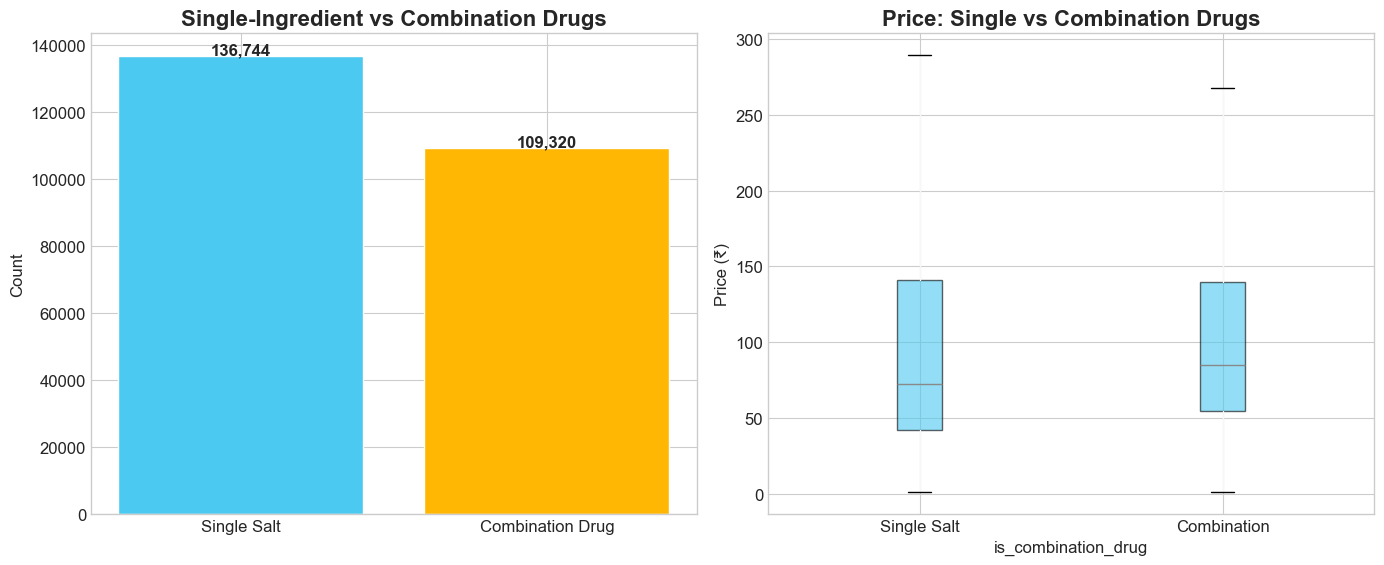

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

combo_counts = df['is_combination_drug'].value_counts()
labels = ['Single Salt', 'Combination Drug']
axes[0].bar(labels, combo_counts.values, color=['#4CC9F0', '#FFB703'], edgecolor='white')
axes[0].set_title('Single-Ingredient vs Combination Drugs')
axes[0].set_ylabel('Count')
for i, v in enumerate(combo_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

df.boxplot(column='price', by='is_combination_drug', ax=axes[1], showfliers=False,
           patch_artist=True, boxprops=dict(facecolor='#4CC9F0', alpha=0.6))
axes[1].set_title('Price: Single vs Combination Drugs')
axes[1].set_xticklabels(['Single Salt', 'Combination'])
axes[1].set_ylabel('Price (\u20B9)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('05_single_vs_combo.png', dpi=150, bbox_inches='tight')
plt.show()

## The Price Gap Investigation
For each unique chemical composition, we investigate how many brands sell it
and what the **per-unit price range** is. I used `price_per_unit` (not raw MRP)
because a ₹100 strip of 10 tablets and a ₹50 strip of 5 cost the same per tablet.

If the same molecule costs 2-3x more from one brand, that's normal marketing.
If it costs 20-50x, that's a systemic issue.

### Compute price statistics

In [20]:
# Group by composition AND formulation type for fair comparison
df['comp_and_type'] = df['full_composition'] + ' | ' + df['pack_type']

price_stats = df.groupby('comp_and_type').agg(
    brand_count=('name', 'count'),
    min_price=('price_per_unit', 'min'),
    max_price=('price_per_unit', 'max'),
    mean_price=('price_per_unit', 'mean'),
    median_price=('price_per_unit', 'median'),
    std_price=('price_per_unit', 'std'),
    cheapest_brand=('price_per_unit', lambda x: df.loc[x.idxmin(), 'name']),
    cheapest_manufacturer=('price_per_unit', lambda x: df.loc[x.idxmin(), 'manufacturer_name']),
    costliest_brand=('price_per_unit', lambda x: df.loc[x.idxmax(), 'name']),
    costliest_manufacturer=('price_per_unit', lambda x: df.loc[x.idxmax(), 'manufacturer_name']),
).reset_index()

price_stats['price_ratio'] = (price_stats['max_price'] / price_stats['min_price']).round(2)

price_stats_filtered = price_stats[price_stats['brand_count'] >= 5].copy()
price_stats_filtered = price_stats_filtered.sort_values('price_ratio', ascending=False)

print(f'Compositions (same formulation) with 5+ brands: {len(price_stats_filtered)}')
print(f'\nTop 10 with HIGHEST price gap (per-unit, same formulation):')
price_stats_filtered[['comp_and_type', 'brand_count', 'min_price', 'max_price', 'price_ratio']].head(10)

Compositions (same formulation) with 5+ brands: 4159

Top 10 with HIGHEST price gap (per-unit, same formulation):


,comp_and_type,brand_count,min_price,max_price,price_ratio
13296,Sodium Chloride (NA) | solution,5,0.06,495.00,8684.21
3040,Cefoperazone (500mg) + Sulbactam (500mg) | vial,443,5.00,31069.00,6213.80
1144,Amphotericin B (50mg) | vial,21,29.51,156330.60,5297.55
12029,Povidone Iodine (5% w/v) | solution,32,0.17,481.60,2892.49
5223,Diclofenac (50mg) + Paracetamol (500mg) | ta...,512,0.02,37.49,2118.36
9810,Metoclopramide (5mg) | syrup,11,0.13,250.00,1875.47
5909,Doxorubicin (Plain) (50mg) | vial,33,10.48,18250.00,1740.75
12013,Povidone Iodine (10% w/v) | solution,18,0.66,1001.00,1516.67
4164,Cisplatin (50mg) | vial,16,5.57,7900.00,1417.96
12049,Povidone Iodine (NA) | solution,6,0.15,193.12,1254.06


### Limitation: Cross-Format Comparisons
Some compositions still show inflated ratios because pack sizes and units differ
(e.g., 500ml IV saline bags vs single-use inhalation bottles priced as 1 unit).
A perfect fix would require parsing the unit of measurement from pack labels,
which is beyond the scope of this analysis.

**Our approach:** I filtered to compositions with 30+ brands of the same formulation
type, where the majority of products are comparable. The deep-dive on 5 common
household medicines provides the cleanest, most relatable comparisons.

### Top 20 price gap chart

Compositions with 30+ brands (same formulation): 1218


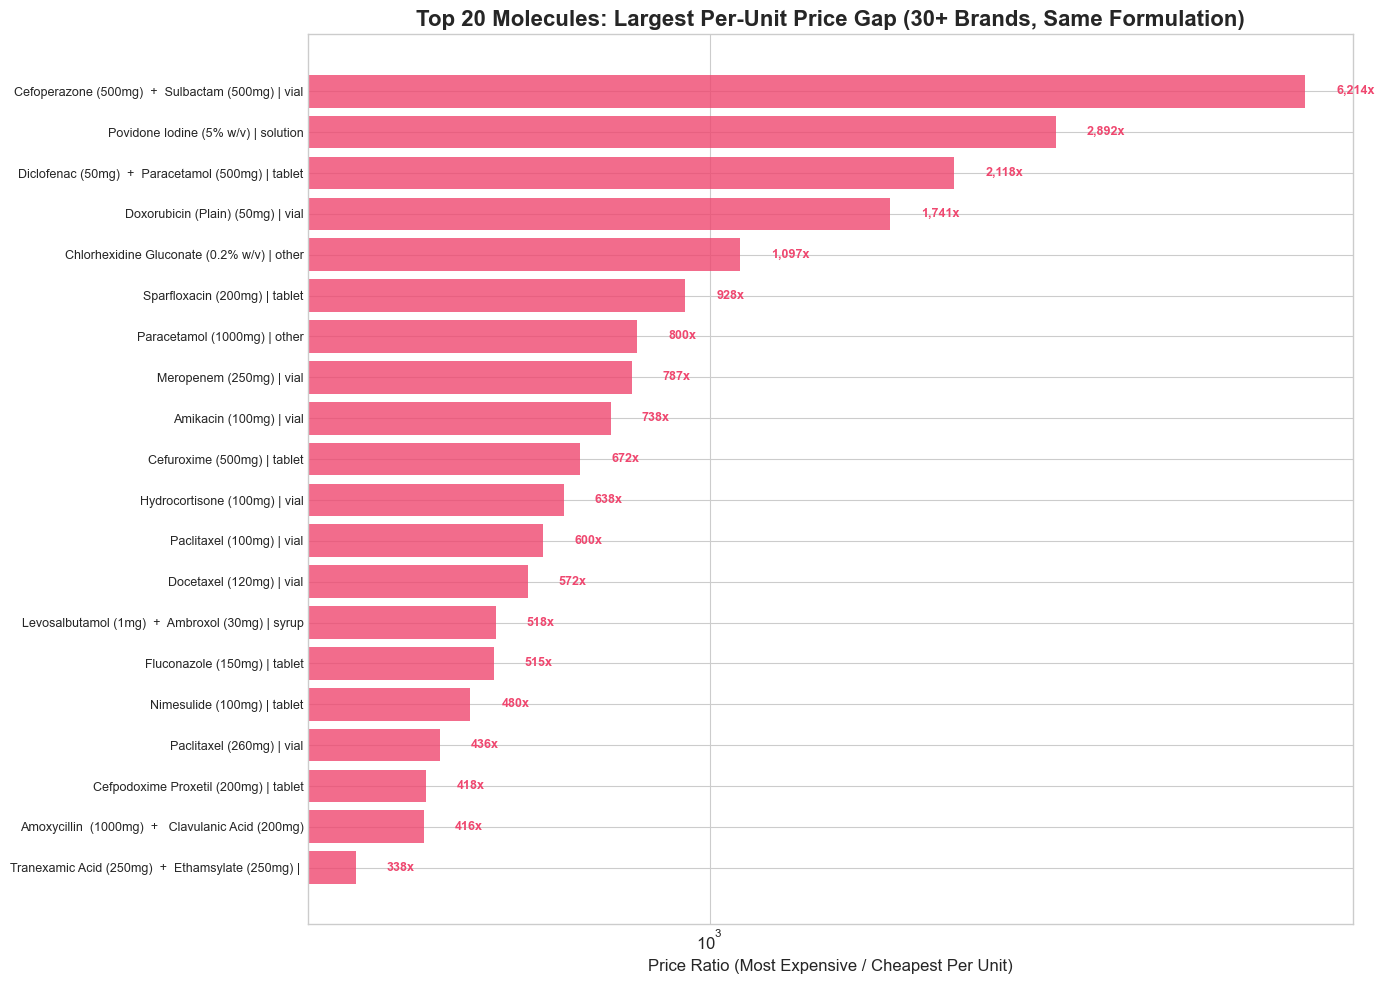

In [21]:
price_stats_clean = price_stats_filtered[price_stats_filtered['brand_count'] >= 30].copy()
price_stats_clean = price_stats_clean.sort_values('price_ratio', ascending=False)

print(f'Compositions with 30+ brands (same formulation): {len(price_stats_clean)}')

top20_gap = price_stats_clean.head(20)

fig, ax = plt.subplots(figsize=(14, 10))
y_pos = range(len(top20_gap))

bars = ax.barh(y_pos, top20_gap['price_ratio'].values, color='#EF476F', alpha=0.8)
ax.set_yticks(y_pos)
labels = [c[:50] for c in top20_gap['comp_and_type'].values]
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Price Ratio (Most Expensive / Cheapest Per Unit)')
ax.set_title('Top 20 Molecules: Largest Per-Unit Price Gap (30+ Brands, Same Formulation)')
ax.invert_yaxis()
ax.set_xscale('log')

for i, row in enumerate(top20_gap.itertuples()):
    ax.text(row.price_ratio * 1.1, i, f'{row.price_ratio:,.0f}x',
            va='center', fontsize=9, fontweight='bold', color='#EF476F')

plt.tight_layout()
plt.savefig('06_top20_price_gap.png', dpi=150, bbox_inches='tight')
plt.show()

### Price Ratio Distribution
How widespread is the price gap? This histogram shows the distribution of
max/min per-unit price ratios across all molecules with 5+ brands.

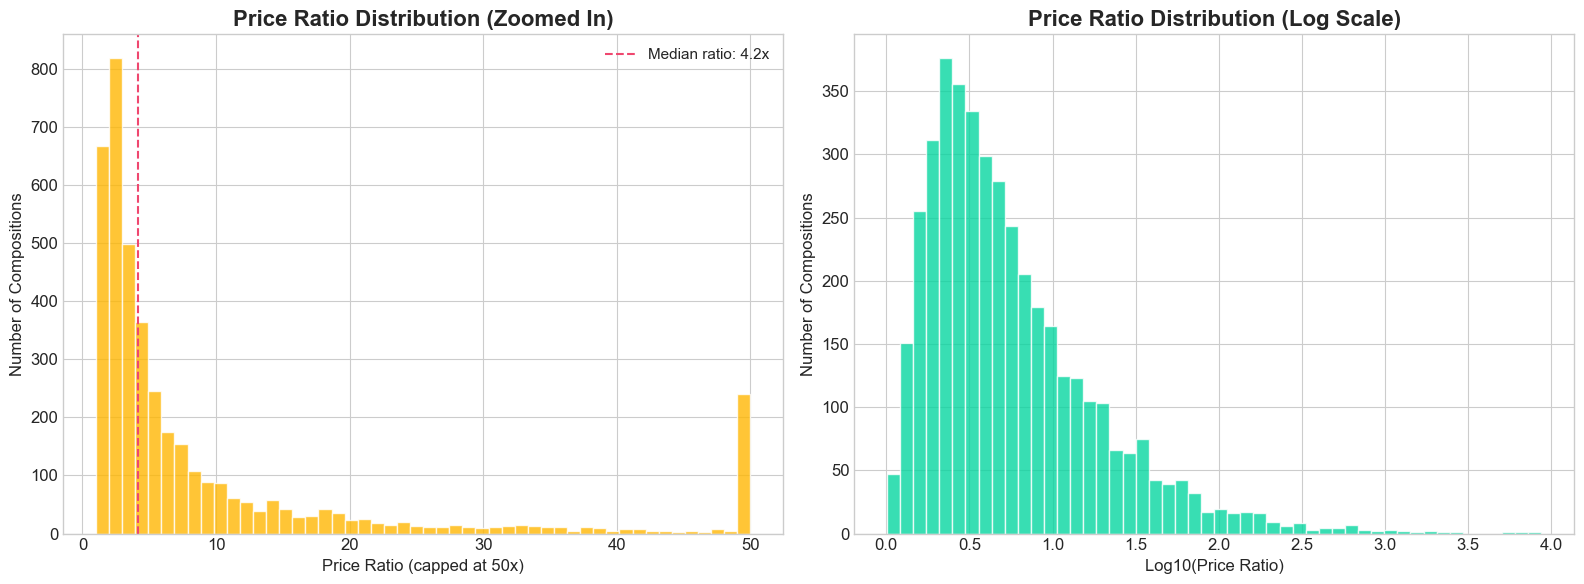


Price Ratio Summary (per unit):
  Median: 4.2x
  Mean: 24.1x
  Compositions with 10x+ gap: 1028
  Compositions with 50x+ gap: 239


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Clipped view (up to 50x) - where most data lives
axes[0].hist(price_stats_filtered['price_ratio'].clip(upper=50), bins=50, 
             color='#FFB703', edgecolor='white', alpha=0.8)
axes[0].axvline(price_stats_filtered['price_ratio'].median(), color='#EF476F', linestyle='--',
                label=f'Median ratio: {price_stats_filtered["price_ratio"].median():.1f}x')
axes[0].set_xlabel('Price Ratio (capped at 50x)')
axes[0].set_ylabel('Number of Compositions')
axes[0].set_title('Price Ratio Distribution (Zoomed In)')
axes[0].legend(fontsize=11)

# Right: Log scale - full picture
axes[1].hist(np.log10(price_stats_filtered['price_ratio']), bins=50,
             color='#06D6A0', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Log10(Price Ratio)')
axes[1].set_ylabel('Number of Compositions')
axes[1].set_title('Price Ratio Distribution (Log Scale)')

plt.tight_layout()
plt.savefig('07_price_ratio_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPrice Ratio Summary (per unit):')
print(f'  Median: {price_stats_filtered["price_ratio"].median():.1f}x')
print(f'  Mean: {price_stats_filtered["price_ratio"].mean():.1f}x')
print(f'  Compositions with 10x+ gap: {(price_stats_filtered["price_ratio"] >= 10).sum()}')
print(f'  Compositions with 50x+ gap: {(price_stats_filtered["price_ratio"] >= 50).sum()}')

### Deep Dive — 5 Medicines Every Indian Knows
Let's look at 5 household-name molecules. These are medicines people actually buy
at pharmacies — making the price gap personal and relatable. Since these are all
tablets, the per-unit comparison is clean and trustworthy.

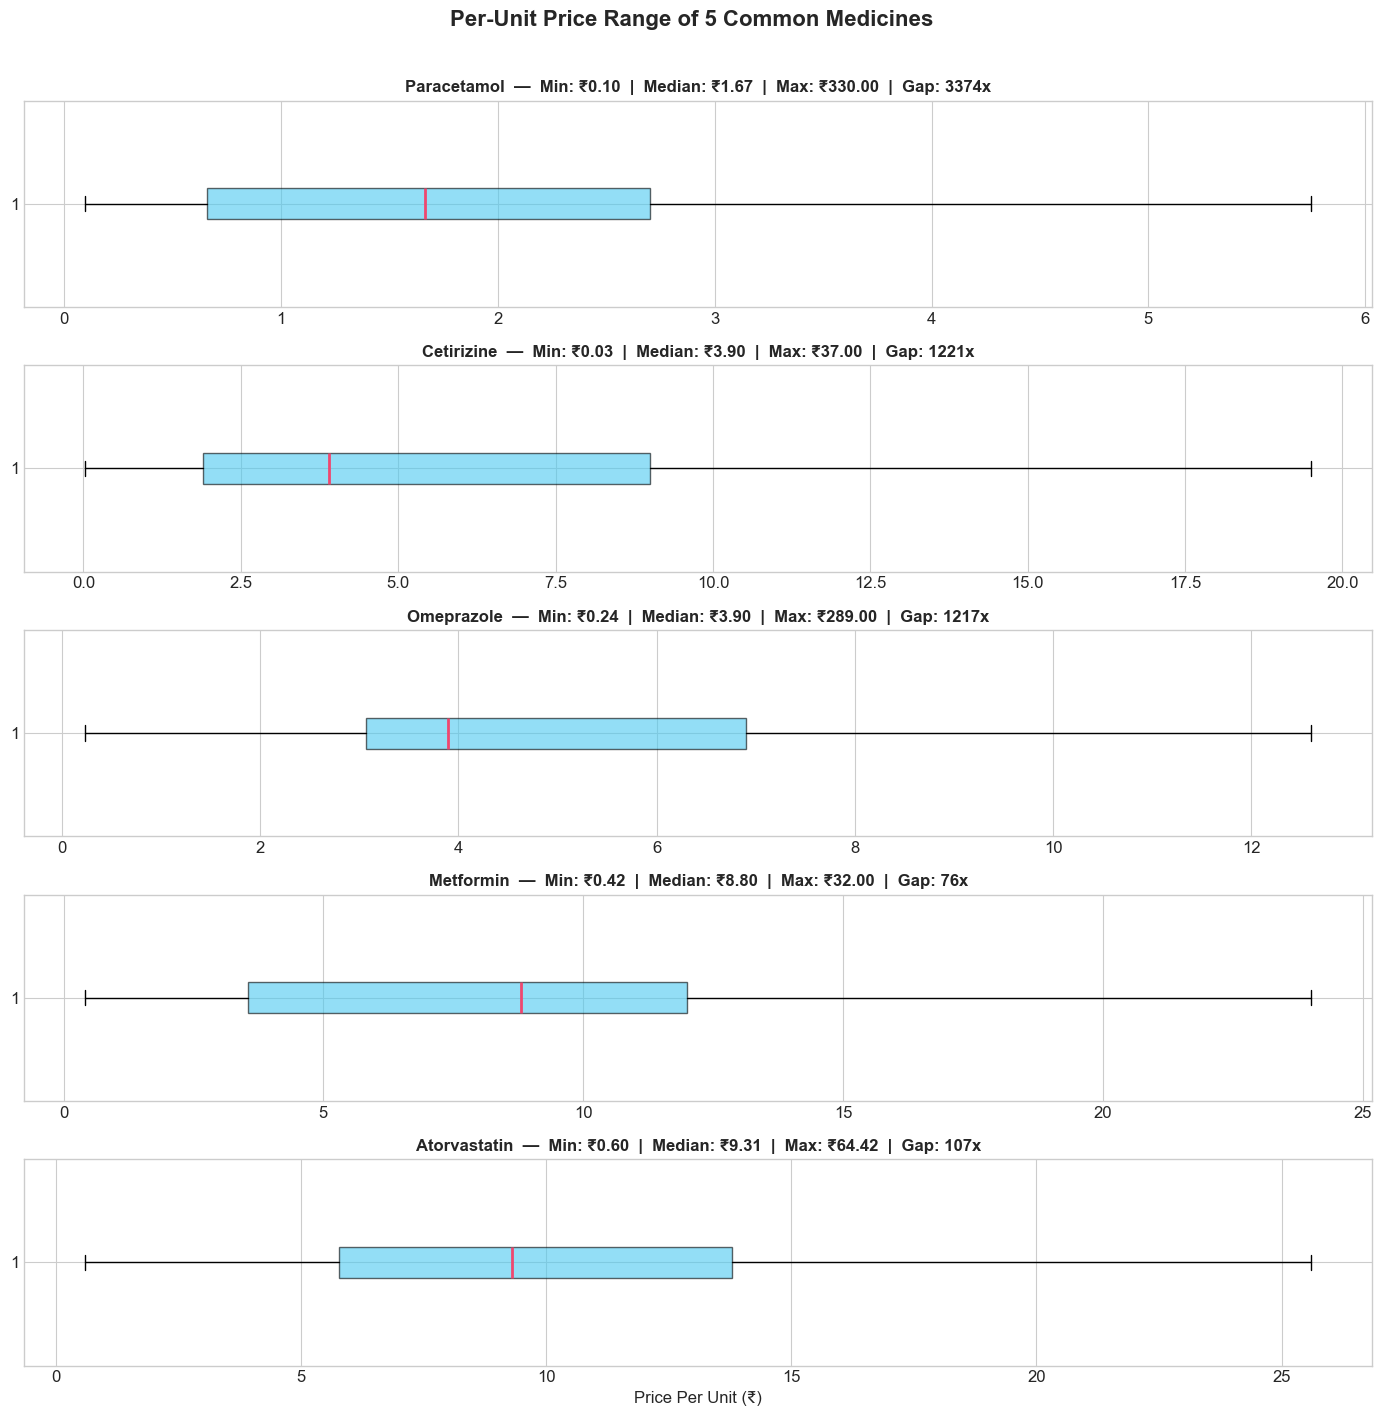

In [23]:
common_molecules = ['Paracetamol', 'Cetirizine', 'Omeprazole', 'Metformin', 'Atorvastatin']

fig, axes = plt.subplots(len(common_molecules), 1, figsize=(14, 14), sharey=False)

for i, mol in enumerate(common_molecules):
    subset = df[df['salt_name'].str.contains(mol, case=False, na=False)]
    if len(subset) > 0:
        prices = subset['price_per_unit'].sort_values()
        axes[i].boxplot(prices, vert=False, patch_artist=True, showfliers=False,
                        boxprops=dict(facecolor='#4CC9F0', alpha=0.6),
                        medianprops=dict(color='#EF476F', linewidth=2))
        
        med = prices.median()
        mn = prices.min()
        mx = prices.max()
        ratio = mx / mn
        
        axes[i].set_title(f'{mol}  —  Min: ₹{mn:.2f}  |  Median: ₹{med:.2f}  |  Max: ₹{mx:.2f}  |  Gap: {ratio:.0f}x',
                          fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Price Per Unit (₹)' if i == len(common_molecules)-1 else '')

plt.suptitle('Per-Unit Price Range of 5 Common Medicines',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('08_common_medicines_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Does Competition Reduce the Price Gap?
If more brands sell the same molecule, does competition drive down the price gap?
I tested this by plotting brand count vs price ratio.

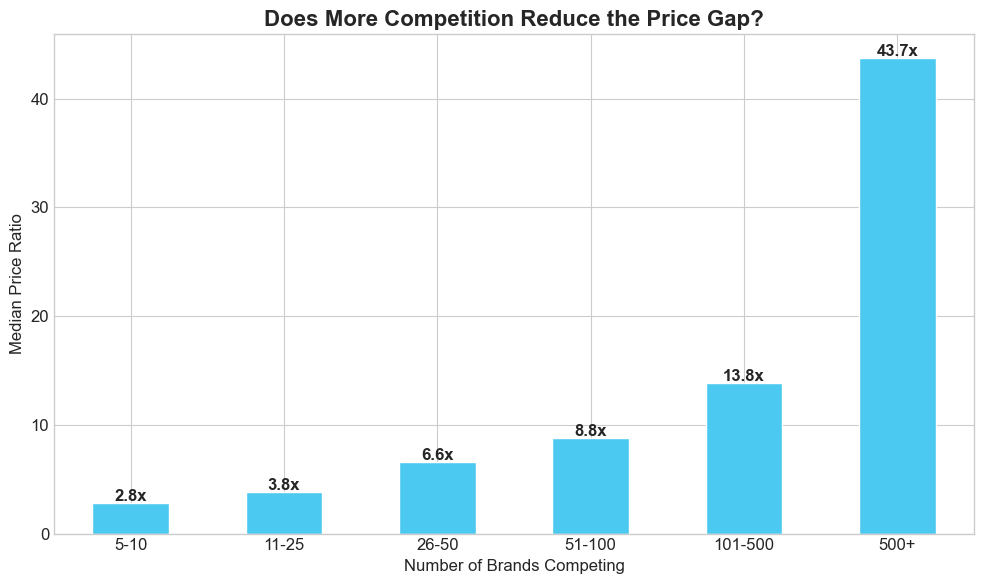

Correlation: 0.072


In [24]:
# Bin compositions by brand count
bins = [5, 10, 25, 50, 100, 500, 5000]
labels = ['5-10', '11-25', '26-50', '51-100', '101-500', '500+']
price_stats_filtered['brand_bin'] = pd.cut(price_stats_filtered['brand_count'], 
                                            bins=bins, labels=labels)

median_by_bin = price_stats_filtered.groupby('brand_bin')['price_ratio'].median()

fig, ax = plt.subplots(figsize=(10, 6))
median_by_bin.plot(kind='bar', color='#4CC9F0', edgecolor='white', ax=ax)
ax.set_xlabel('Number of Brands Competing')
ax.set_ylabel('Median Price Ratio')
ax.set_title('Does More Competition Reduce the Price Gap?')
ax.tick_params(axis='x', rotation=0)

for i, v in enumerate(median_by_bin.values):
    ax.text(i, v + 0.2, f'{v:.1f}x', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('09_competition_vs_pricegap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Correlation: {price_stats_filtered["brand_count"].corr(price_stats_filtered["price_ratio"]):.3f}')

**Insight:** Contrary to expectation, more competition does NOT reduce the price gap — 
it increases it. Molecules with 500+ brands have a median 43.7x gap vs just 2.8x for 
molecules with 5-10 brands. This suggests that high-competition markets allow ultra-cheap 
generics to coexist alongside premium brands, widening the spread rather than compressing it. 
The implication: consumers in crowded markets have the most to gain by switching to generics, 
but also the most to lose by defaulting to a branded option.

## Manufacturer Premium Analysis
For each manufacturer, I calculated how their per-unit prices compare to the market median for the same composition. A premium ratio > 1.0 means the manufacturer charges above median; < 1.0 means below.

### Manufacturer premium index

In [25]:
comp_median = df.groupby('full_composition')['price_per_unit'].median().reset_index()
comp_median.columns = ['full_composition', 'comp_median_price']

df = df.merge(comp_median, on='full_composition', how='left')
df['premium_ratio'] = (df['price_per_unit'] / df['comp_median_price']).round(3)

mfg_premium = df.groupby('manufacturer_name').agg(
    avg_premium=('premium_ratio', 'mean'),
    product_count=('name', 'count'),
    avg_price=('price_per_unit', 'mean')
).reset_index()

mfg_premium = mfg_premium[mfg_premium['product_count'] >= 50]
mfg_premium = mfg_premium.sort_values('avg_premium', ascending=False)

print('Top 15 MOST EXPENSIVE manufacturers (per-unit premium):')
mfg_premium[['manufacturer_name', 'avg_premium', 'product_count', 'avg_price']].head(15)

Top 15 MOST EXPENSIVE manufacturers (per-unit premium):


,manufacturer_name,avg_premium,product_count,avg_price
7120,Venus Remedies Ltd,26.92,139,416.92
7360,Win-Medicare Pvt Ltd,8.80,150,55.70
5762,Roma Pharma Pvt Ltd,8.05,93,63.72
5434,Qgensun Healthcare,7.41,56,43.69
6696,Taj Pharma India Ltd,5.35,339,470.96
7268,Vytrax Healthcare,5.12,71,262.02
2897,Gufic Bioscience Ltd,4.39,123,925.15
2115,Dr. Edwin Lab,4.37,187,111.93
6376,Somkee India Private Limited,4.29,54,224.68
4519,Modi Mundi Pharma Pvt Ltd,4.26,67,179.10


### Most vs Least expensive manufacturers

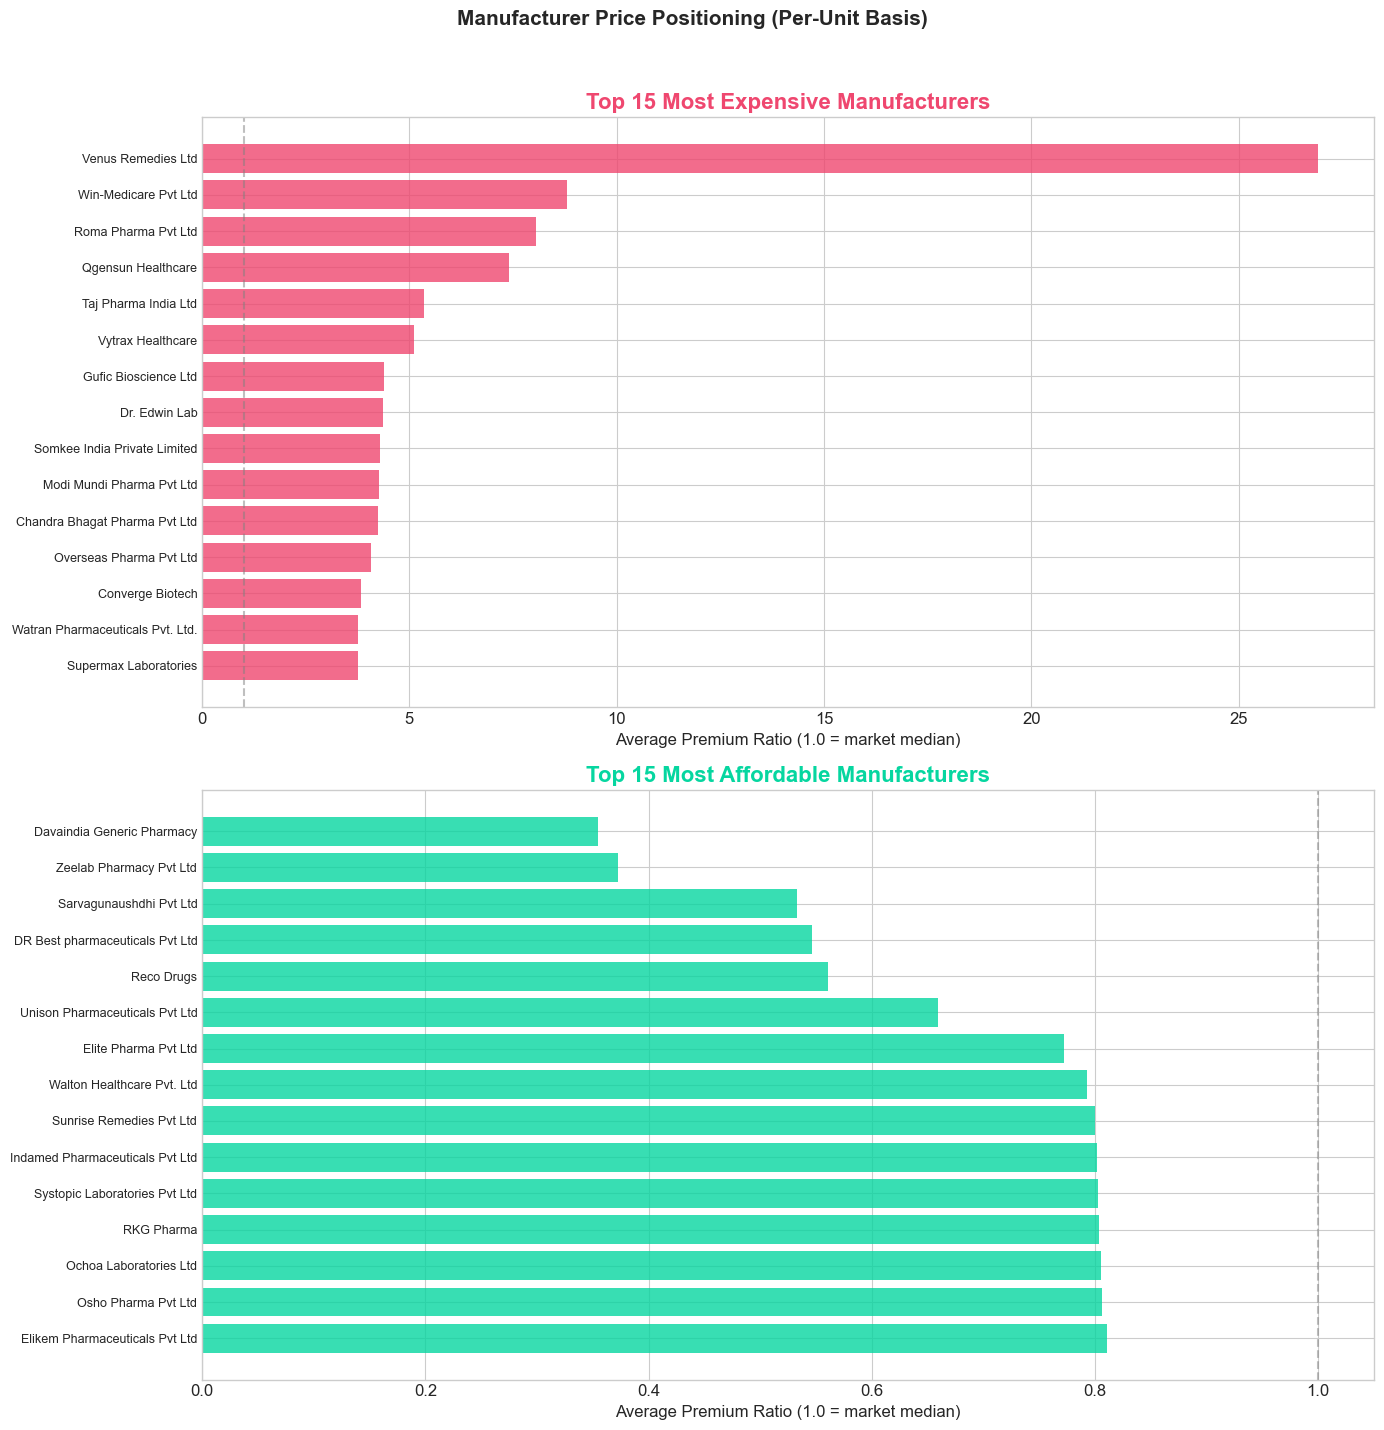

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

top_expensive = mfg_premium.head(15)
axes[0].barh(range(len(top_expensive)), top_expensive['avg_premium'].values, color='#EF476F', alpha=0.8)
axes[0].set_yticks(range(len(top_expensive)))
axes[0].set_yticklabels([n[:35] for n in top_expensive['manufacturer_name'].values], fontsize=9)
axes[0].set_xlabel('Average Premium Ratio (1.0 = market median)')
axes[0].set_title('Top 15 Most Expensive Manufacturers', color='#EF476F')
axes[0].axvline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[0].invert_yaxis()

top_affordable = mfg_premium.tail(15).sort_values('avg_premium', ascending=True)
axes[1].barh(range(len(top_affordable)), top_affordable['avg_premium'].values, color='#06D6A0', alpha=0.8)
axes[1].set_yticks(range(len(top_affordable)))
axes[1].set_yticklabels([n[:35] for n in top_affordable['manufacturer_name'].values], fontsize=9)
axes[1].set_xlabel('Average Premium Ratio (1.0 = market median)')
axes[1].set_title('Top 15 Most Affordable Manufacturers', color='#06D6A0')
axes[1].axvline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[1].invert_yaxis()

plt.suptitle('Manufacturer Price Positioning (Per-Unit Basis)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('10_manufacturer_premium.png', dpi=150, bbox_inches='tight')
plt.show()

### Manufacturer x Molecule Heatmap
This heatmap shows the median per-unit price for each combination of top manufacturer and top molecule. Dark red = expensive, light yellow = affordable.

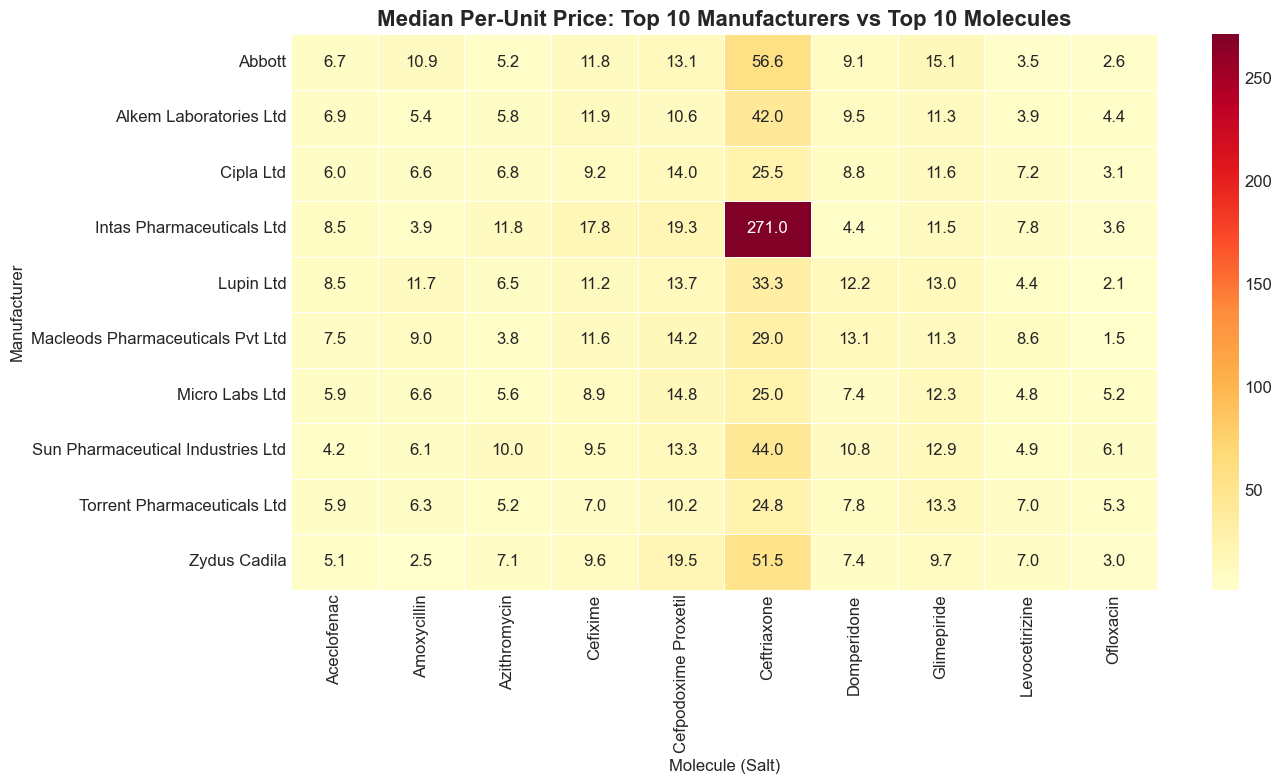

In [27]:
top10_mfg = df['manufacturer_name'].value_counts().head(10).index
top10_salt = df['salt_name'].value_counts().head(10).index

subset = df[df['manufacturer_name'].isin(top10_mfg) & df['salt_name'].isin(top10_salt)]
pivot = subset.pivot_table(values='price_per_unit', index='manufacturer_name',
                           columns='salt_name', aggfunc='median')

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Median Per-Unit Price: Top 10 Manufacturers vs Top 10 Molecules')
ax.set_xlabel('Molecule (Salt)')
ax.set_ylabel('Manufacturer')

plt.tight_layout()
plt.savefig('11_manufacturer_salt_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Therapeutic Category Analysis


### Therapeutic Category Mapping
I manually mapped 30 of the most common molecules to 8 therapeutic categories. 
This covers around 82,000 medicines (~33% of the dataset). While not exhaustive, these 
are the most widely prescribed and recognized molecules — making the analysis 
relatable and the sample size statistically robust.

In [28]:
therapy_map = {
    'Paracetamol': 'Pain/Fever', 'Ibuprofen': 'Pain/Fever', 'Diclofenac': 'Pain/Fever',
    'Aceclofenac': 'Pain/Fever', 'Aspirin': 'Pain/Fever',
    'Amoxycillin': 'Antibiotics', 'Azithromycin': 'Antibiotics', 'Ciprofloxacin': 'Antibiotics',
    'Cefixime': 'Antibiotics', 'Ofloxacin': 'Antibiotics', 'Levofloxacin': 'Antibiotics',
    'Metformin': 'Diabetes', 'Glimepiride': 'Diabetes', 'Sitagliptin': 'Diabetes',
    'Atorvastatin': 'Cardiac', 'Amlodipine': 'Cardiac', 'Telmisartan': 'Cardiac',
    'Losartan': 'Cardiac', 'Ramipril': 'Cardiac',
    'Omeprazole': 'Gastric', 'Pantoprazole': 'Gastric', 'Rabeprazole': 'Gastric',
    'Cetirizine': 'Allergy', 'Levocetirizine': 'Allergy', 'Fexofenadine': 'Allergy',
    'Fluoxetine': 'Mental Health', 'Escitalopram': 'Mental Health', 'Sertraline': 'Mental Health',
    'Montelukast': 'Respiratory', 'Salbutamol': 'Respiratory',
}

df['therapy_category'] = df['salt_name'].map(therapy_map).fillna('Other')
df_therapy = df[df['therapy_category'] != 'Other']
print(df_therapy['therapy_category'].value_counts())


therapy_category
Antibiotics      32665
Pain/Fever       16673
Cardiac           8904
Allergy           8016
Diabetes          7537
Gastric           6436
Respiratory       1178
Mental Health      718
Name: count, dtype: int64


### Price-per-unit distribution by Therapeutic category

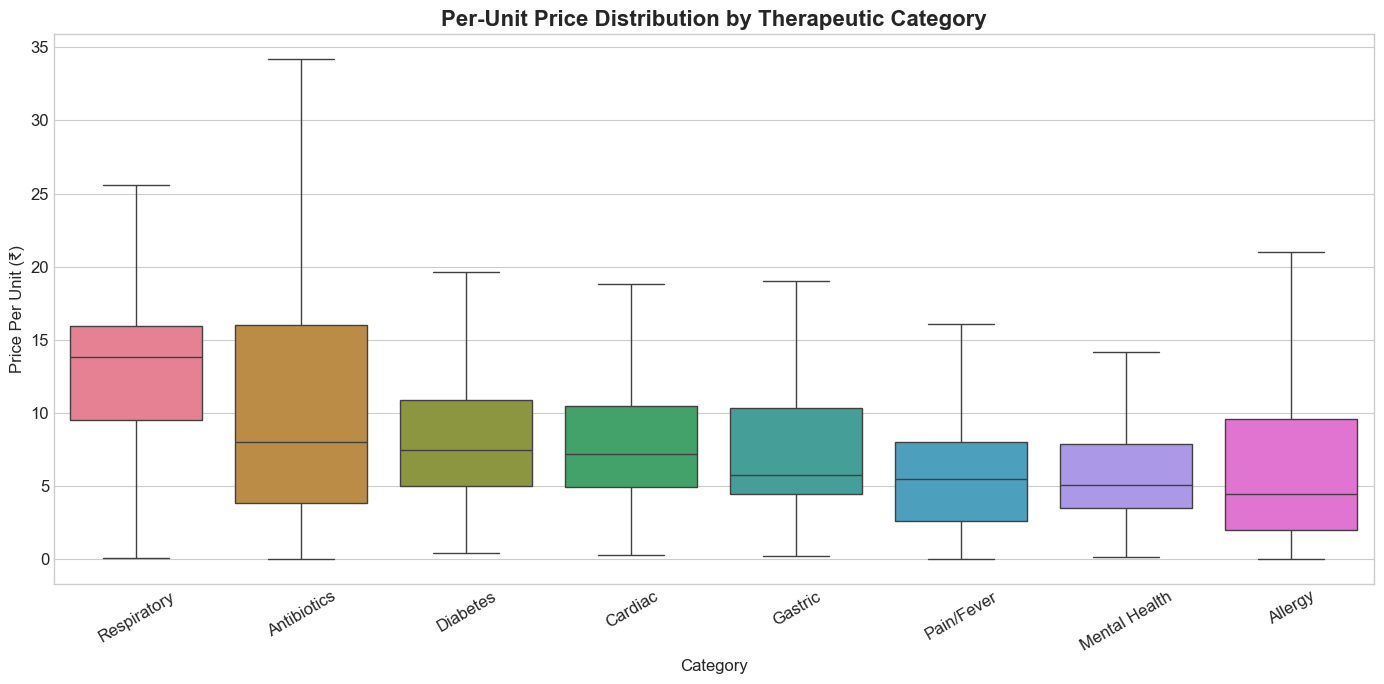

In [29]:
fig, ax = plt.subplots(figsize=(14, 7))
order = df_therapy.groupby('therapy_category')['price_per_unit'].median().sort_values(ascending=False).index
sns.boxplot(data=df_therapy, x='therapy_category', y='price_per_unit', order=order,
            palette='husl', showfliers=False, ax=ax)
ax.set_title('Per-Unit Price Distribution by Therapeutic Category')
ax.set_xlabel('Category')
ax.set_ylabel('Price Per Unit (\u20B9)')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('12_therapy_category_prices.png', dpi=150, bbox_inches='tight')
plt.show()


### Which Drug Categories Have the Worst Price Gap?
I calculated the median per-unit price ratio (most expensive / cheapest) for each 
therapeutic category. Categories where patients overpay the most appear at the top — 
these are the areas where switching to a generic alternative would save the most money.

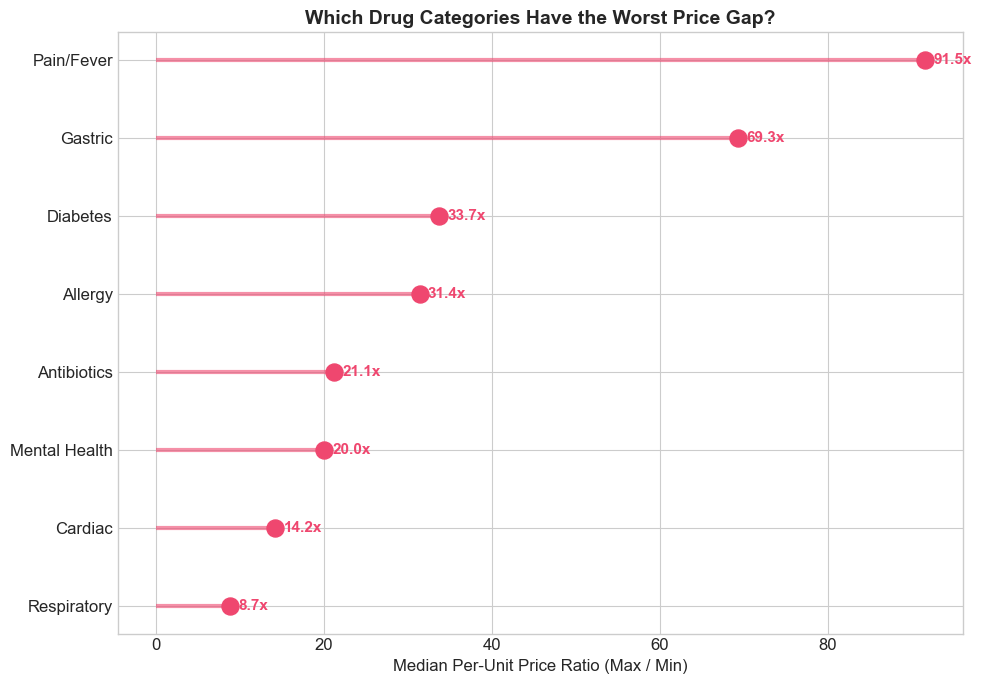

In [30]:
therapy_ratio = df_therapy.merge(
    price_stats_filtered[['comp_and_type', 'price_ratio']],
    left_on=df_therapy['full_composition'] + ' | ' + df_therapy['pack_type'],
    right_on='comp_and_type', how='inner'
).groupby('therapy_category')['price_ratio'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

# Draw lines (stems)
ax.hlines(y=range(len(therapy_ratio)), xmin=0, xmax=therapy_ratio.values,
          color='#EF476F', alpha=0.6, linewidth=3)

# Draw dots
ax.scatter(therapy_ratio.values, range(len(therapy_ratio)), 
           color='#EF476F', s=150, zorder=3)

ax.set_yticks(range(len(therapy_ratio)))
ax.set_yticklabels(therapy_ratio.index, fontsize=12)
ax.set_xlabel('Median Per-Unit Price Ratio (Max / Min)', fontsize=12)
ax.set_title('Which Drug Categories Have the Worst Price Gap?', fontsize=14, fontweight='bold')

# Add value labels
for i, v in enumerate(therapy_ratio.values):
    ax.text(v + 1, i, f'{v:.1f}x', va='center', fontsize=11, fontweight='bold', color='#EF476F')

plt.tight_layout()
plt.savefig('13_therapy_price_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

## Premium-Priced Medicines: The Other Side of the Market
While most medicines cost under ₹100, a small segment of specialty drugs — primarily 
cancer treatments, immunotherapy, and biologics — cost lakhs per unit. These were flagged 
during cleaning and kept in the dataset. Let's explore them.

In [31]:
premium = df[df['is_premium_priced'] == True][
    ['name', 'price', 'manufacturer_name', 'salt_name', 'pack_type', 'price_per_unit']
].sort_values('price', ascending=False)

print(f'Total premium-priced medicines: {len(premium)}')
print(f'Price range: ₹{premium["price"].min():,.0f} to ₹{premium["price"].max():,.0f}')

# Top therapeutic areas in premium segment
print(f'\nTop salts in premium segment:')
print(premium['salt_name'].value_counts().head(10))

Total premium-priced medicines: 245
Price range: ₹25,400 to ₹436,000

Top salts in premium segment:
salt_name
Abiraterone Acetate    26
Bevacizumab            23
Rituximab              21
Trastuzumab            16
Tenecteplase            9
Everolimus              5
Ruxolitinib             5
Plerixafor              5
Octreotide acetate      4
Rucaparib               4
Name: count, dtype: int64


### Most expensive medicines & manufacturers

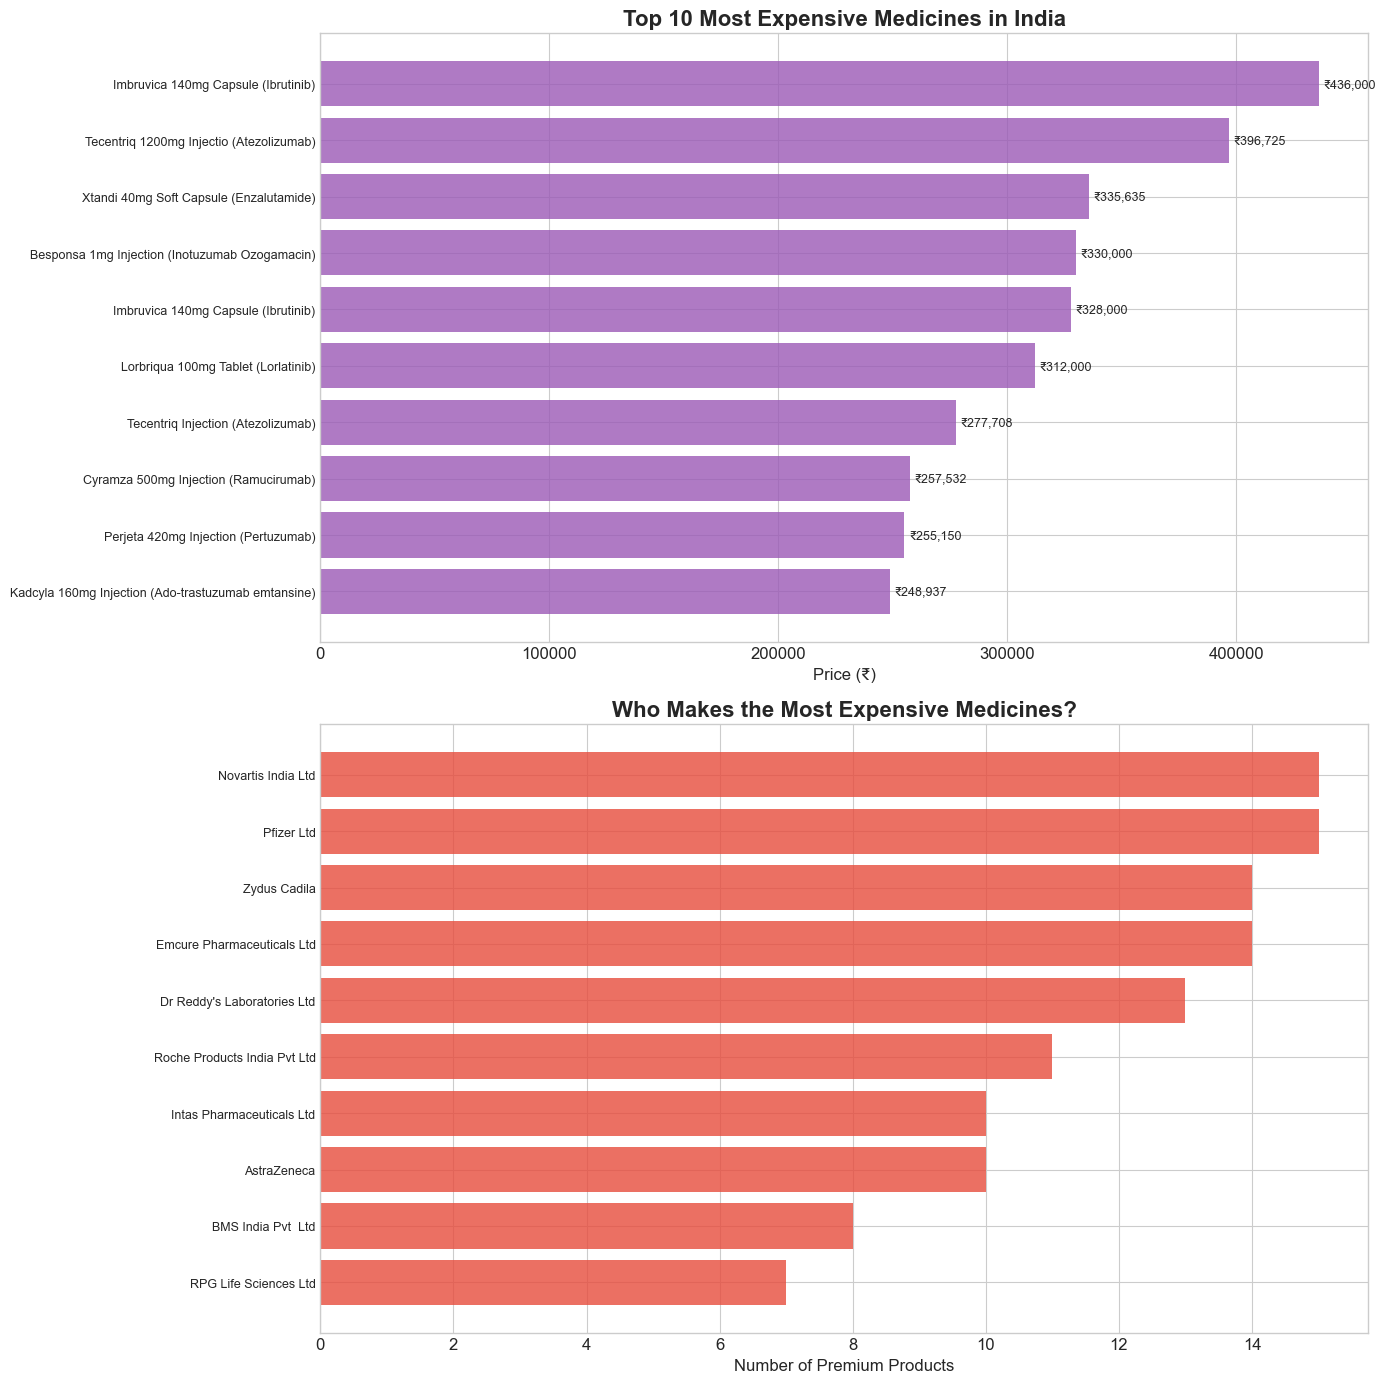

In [32]:
# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Left: Top 10 most expensive medicines
top10 = premium.head(10)
axes[0].barh(range(len(top10)), top10['price'].values, color='#9B59B6', alpha=0.8)
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels([f"{n[:25]} ({s})" for n, s in 
    zip(top10['name'].values, top10['salt_name'].values)], fontsize=9)
axes[0].set_xlabel('Price (₹)')
axes[0].set_title('Top 10 Most Expensive Medicines in India', fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(top10['price'].values):
    axes[0].text(v + 2000, i, f'₹{v:,.0f}', va='center', fontsize=9)

# Right: Manufacturer share of premium segment
top_mfg_premium = premium['manufacturer_name'].value_counts().head(10)
axes[1].barh(range(len(top_mfg_premium)), top_mfg_premium.values, color='#E74C3C', alpha=0.8)
axes[1].set_yticks(range(len(top_mfg_premium)))
axes[1].set_yticklabels(top_mfg_premium.index, fontsize=9)
axes[1].set_xlabel('Number of Premium Products')
axes[1].set_title('Who Makes the Most Expensive Medicines?', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('15_premium_medicines.png', dpi=150, bbox_inches='tight')
plt.show()

## The Affordability Index — A Custom Metric
I created an **Affordability Index (AI)** that scores each medicine on how close
its per-unit price is to the cheapest available alternative for the same composition.
- **AI = 1.0** — you're buying the cheapest option
- **AI = 5.0** — you're paying 5x more per tablet/ml than necessary
- **AI = 10.0** — you're paying 10x more for the same molecule


In [33]:
comp_min = df.groupby('full_composition')['price_per_unit'].min().reset_index()
comp_min.columns = ['full_composition', 'min_comp_price_per_unit']

df = df.merge(comp_min, on='full_composition', how='left')
df['affordability_index'] = (df['price_per_unit'] / df['min_comp_price_per_unit']).round(2)

overpriced = df[df['affordability_index'] > 2.0]
print(f'Medicines costing 2x+ more per unit than cheapest: {len(overpriced):,} ({len(overpriced)/len(df)*100:.1f}%)')
print(f'Medicines costing 5x+ more: {(df["affordability_index"] > 5.0).sum():,}')
print(f'Medicines costing 10x+ more: {(df["affordability_index"] > 10.0).sum():,}')


Medicines costing 2x+ more per unit than cheapest: 202,090 (82.1%)
Medicines costing 5x+ more: 131,113
Medicines costing 10x+ more: 78,610


### Affordability visualization

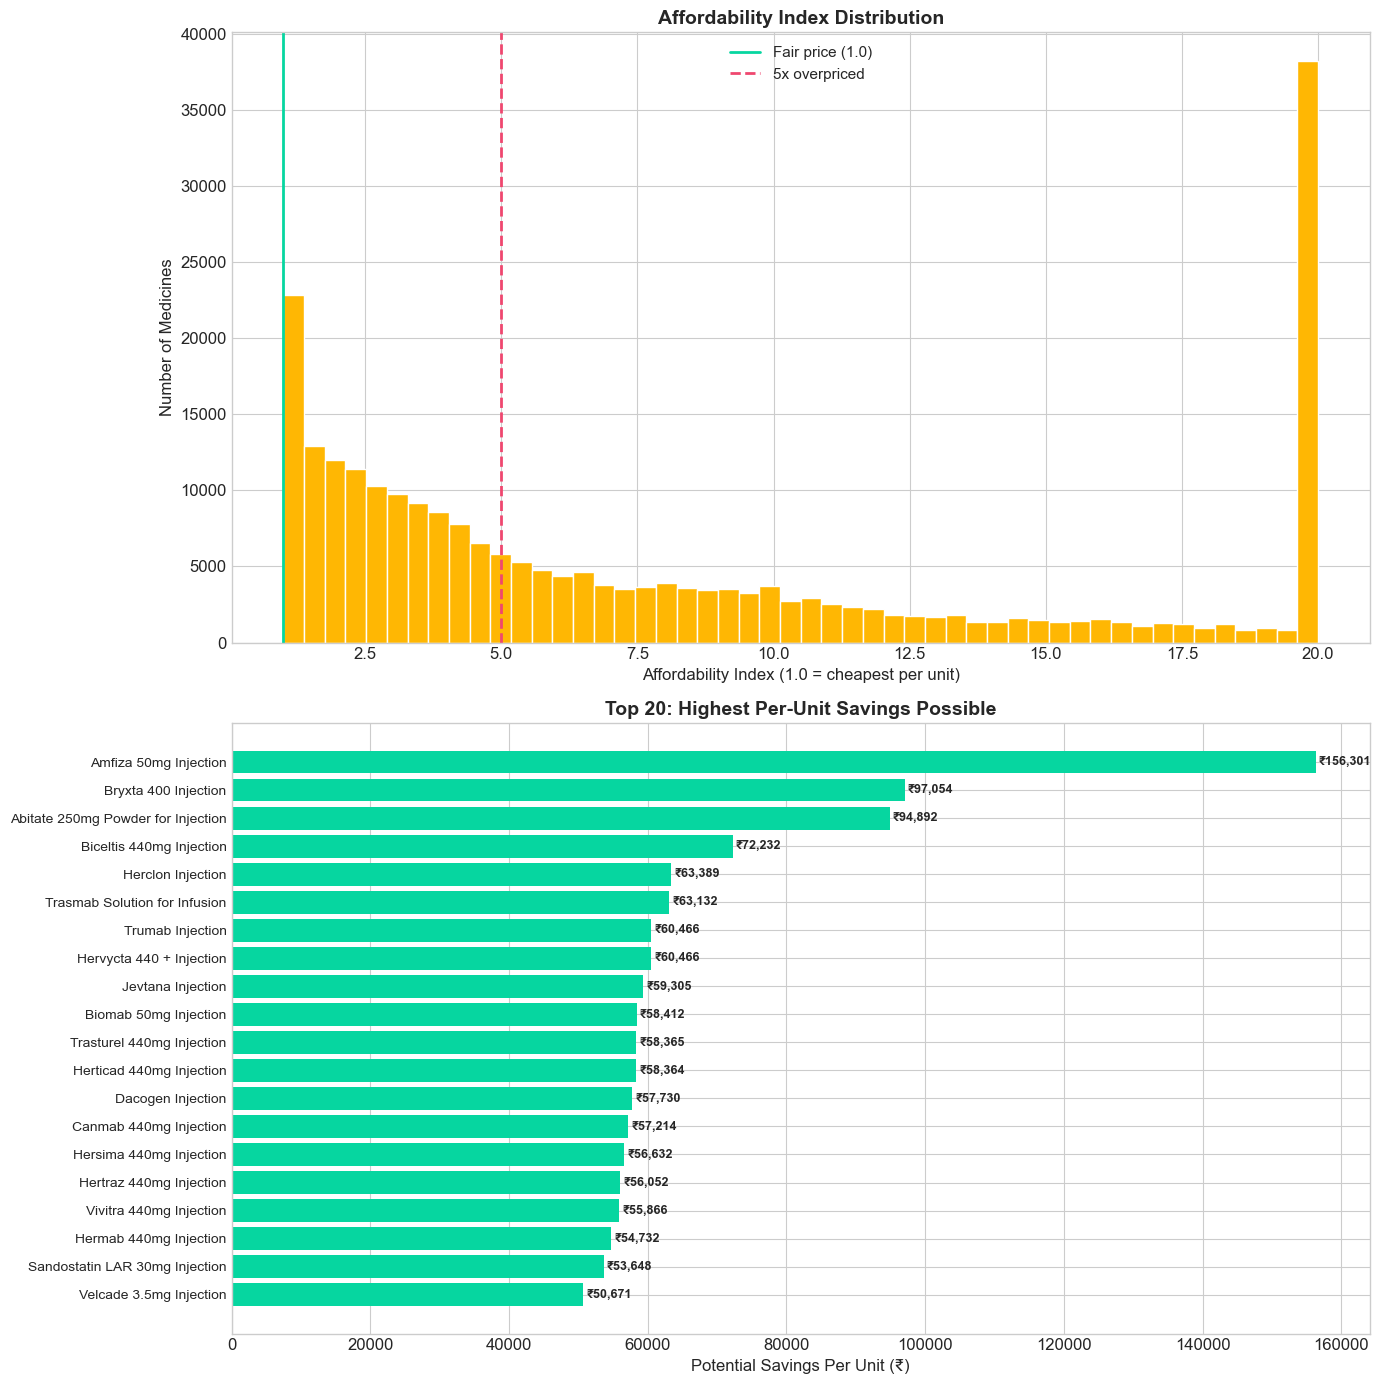

In [34]:
df['potential_savings_per_unit'] = df['price_per_unit'] - df['min_comp_price_per_unit']

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Top: Affordability Index distribution
axes[0].hist(df['affordability_index'].clip(upper=20), bins=50, color='#FFB703', edgecolor='white')
axes[0].set_xlabel('Affordability Index (1.0 = cheapest per unit)')
axes[0].set_ylabel('Number of Medicines')
axes[0].set_title('Affordability Index Distribution', fontsize=14, fontweight='bold')
axes[0].axvline(1.0, color='#06D6A0', linewidth=2, label='Fair price (1.0)')
axes[0].axvline(5.0, color='#EF476F', linewidth=2, linestyle='--', label='5x overpriced')
axes[0].legend(fontsize=11)

# Bottom: Top 20 savings
top_savings = df.nlargest(20, 'potential_savings_per_unit')[
    ['name', 'manufacturer_name', 'price_per_unit', 'min_comp_price_per_unit',
     'potential_savings_per_unit']]
axes[1].barh(range(len(top_savings)), top_savings['potential_savings_per_unit'].values, color='#06D6A0')
axes[1].set_yticks(range(len(top_savings)))
axes[1].set_yticklabels([n[:40] for n in top_savings['name'].values], fontsize=10)
axes[1].set_xlabel('Potential Savings Per Unit (₹)')
axes[1].set_title('Top 20: Highest Per-Unit Savings Possible', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

for i, v in enumerate(top_savings['potential_savings_per_unit'].values):
    axes[1].text(v + 500, i, f'₹{v:,.0f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('14_affordability_index.png', dpi=150, bbox_inches='tight')
plt.show()

## Smart Switch Guide
For 10 well-known molecules, here’s the cheapest vs most expensive brand — and how much you save per unit by switching.

In [35]:
common = ['Paracetamol', 'Cetirizine', 'Omeprazole', 'Metformin', 'Atorvastatin',
          'Azithromycin', 'Amoxycillin', 'Pantoprazole', 'Amlodipine', 'Telmisartan']

recommendations = []
for mol in common:
    # Find the most common full_composition for this molecule
    mol_data = df[df['salt_name'].str.contains(mol, case=False, na=False)]
    if len(mol_data) == 0:
        continue
    
    top_comp = mol_data['full_composition'].value_counts().index[0]
    subset = mol_data[mol_data['full_composition'] == top_comp]
    
    # Filter to most common formulation type
    most_common_type = subset['pack_type'].value_counts().index[0]
    subset = subset[subset['pack_type'] == most_common_type]
    
    if len(subset) > 1:
        cheapest = subset.loc[subset['price_per_unit'].idxmin()]
        costliest = subset.loc[subset['price_per_unit'].idxmax()]
        recommendations.append({
            'Molecule': mol,
            'Composition': top_comp,
            'Form': most_common_type,
            'Cheapest Brand': cheapest['name'],
            'Per Unit': f'₹{cheapest["price_per_unit"]:.2f}',
            'Most Expensive': costliest['name'],
            'Per Unit ': f'₹{costliest["price_per_unit"]:.2f}',
            'Savings/Unit': f'₹{costliest["price_per_unit"] - cheapest["price_per_unit"]:.2f}',
            'Ratio': f'{costliest["price_per_unit"]/cheapest["price_per_unit"]:.1f}x'
        })

rec_df = pd.DataFrame(recommendations)
print('\n*** SMART SWITCH GUIDE: Per-Unit Price Comparison (Same Composition & Formulation) ***')
display(rec_df)


*** SMART SWITCH GUIDE: Per-Unit Price Comparison (Same Composition & Formulation) ***


,Molecule,Composition,Form,Cheapest Brand,Per Unit,Most Expensive,Per Unit,Savings/Unit,Ratio
0,Paracetamol,Paracetamol (650mg),tablet,Alice 650mg Tablet,₹0.33,Paraterm Tablet,₹23.80,₹23.47,71.9x
1,Cetirizine,Levocetirizine (5mg) + Montelukast (10mg),tablet,Pilzine M 5mg/10mg Tablet,₹0.77,Migron-L 5mg/10mg Tablet,₹24.16,₹23.39,31.4x
2,Omeprazole,Omeprazole (20mg),capsule,Omey 20mg Capsule,₹0.28,ON Capsule,₹11.79,₹11.51,42.1x
3,Metformin,Metformin (500mg),tablet,Metbetic Tablet,₹0.42,GD Met 500mg Tablet,₹16.00,₹15.58,38.1x
4,Atorvastatin,Atorvastatin (10mg),tablet,Atorastin 10mg Tablet,₹0.60,Avastral 10mg Tablet,₹23.10,₹22.50,38.5x
5,Azithromycin,Azithromycin (500mg),tablet,TN 500 Tablet,₹1.10,Azito 500mg Tablet,₹69.51,₹68.41,63.1x
6,Amoxycillin,Amoxycillin (500mg) + Clavulanic Acid (125mg),tablet,Apcil Tablet,₹0.70,Kevimox-CV Tablet,₹219.60,₹218.90,314.6x
7,Pantoprazole,Pantoprazole (40mg),tablet,Pds 40mg Tablet,₹0.74,Pendox 40mg Tablet,₹51.00,₹50.26,69.3x
8,Amlodipine,Amlodipine (5mg) + Atenolol (50mg),tablet,Amoline-AT Tablet,₹0.80,AT M 5 mg/50 mg Tablet,₹50.83,₹50.03,63.5x
9,Telmisartan,Telmisartan (40mg),tablet,Telmisoft 40 Tablet,₹0.65,Micartel 40mg Tablet,₹36.55,₹35.91,56.2x


# Key Findings

## 1. The Price Gap is Real and Massive
- The median per-unit price ratio across compositions is **4.2x**
- **1,028** compositions have a per-unit price gap exceeding 10x
- For the same Paracetamol 650mg tablet: cheapest is ₹0.33, most expensive is ₹23.80 — a **71.9x** markup

## 2. More Competition ≠ Lower Price Gaps
- Correlation between brand count and price ratio: **0.072** (near zero)
- Molecules with 500+ brands have a **43.7x** median gap vs just **2.8x** for 5-10 brands
- More players = wider spread, not tighter pricing

## 3. Everyday Medicines Have the Worst Gaps
- **Pain/Fever** drugs have the highest median price gap at **91.5x**
- **Gastric** drugs follow at **69.3x**
- These are the medicines regular people buy most often

## 4. Some Manufacturers Consistently Overcharge
- **Venus Remedies Ltd** charges **26.9x** the market median per unit
- **Davaindia Generic Pharmacy** charges only **0.3x** the median — 70% below market

## 5. The Premium Segment
- **245** medicines cost above ₹25,000 — dominated by cancer and immunotherapy drugs
- India's most expensive medicine: **Imbruvica 140mg Capsule** at **₹4,36,000**
- Premium segment dominated by Novartis, Pfizer, and Zydus Cadila

## 6. Single vs Combination Drugs
- Combination drugs cost **~17% more** at the median than single-ingredient medicines
- **56%** of medicines are single-ingredient formulations

## 7. Actionable Insight: The Smart Switch
- **82.1%** of medicines cost 2x+ more per unit than the cheapest alternative
- For 10 common medicines, switching to the cheapest same-composition, same-formulation brand saves **₹23–₹219 per unit**

## Tools & Libraries Used
- **Python** — Pandas, NumPy, Matplotlib, Seaborn, Regex
- **Jupyter Notebook** — Interactive analysis and visualization
- **Dataset** — Kaggle A-Z Medicine Dataset of India (253,973 medicines)

# Limitations & Future Work

## Limitations
1. **Cross-format noise**: Some price ratios may still be inflated where different delivery formats (e.g., 5ml sachet vs 500ml bottle) share the same composition. A perfect fix would require parsing units of measurement from pack labels.
2. **Therapeutic mapping coverage**: Our therapy category analysis covers ~33% of the dataset (30 common molecules across 8 categories). Expanding this would require a medical taxonomy database.
3. **No time dimension**: This is a single snapshot. We cannot tell if prices are trending up or down over time.
4. **Pack quantity extraction**: The first number in `pack_size_label` is used as quantity. In rare cases (e.g., "strip of 10 tablet sr"), this heuristic may misinterpret the label.

## Future Work
1. **Time-series analysis** — Track price changes over months/years if historical data becomes available
2. **Jan Aushadhi comparison** — Scrape government pharmacy prices to benchmark against market rates
3. **Interactive web app** — Build a tool where users type a medicine name and instantly see cheaper alternatives
4. **ML-based classification** — Auto-classify medicines into therapeutic categories using NLP on composition text

---

### About This Project
**Author:** Daksh Malhotra  
**Program:** B.Tech Engineering Physics, Delhi Technological University (DTU)  
**Dataset:** [A-Z Medicine Dataset of India](https://www.kaggle.com/datasets/shudhanshusingh/az-medicine-dataset-of-india) (Kaggle)  

*This analysis is for educational purposes. Always consult a qualified medical professional before switching medications.*